## Table of Contents:
* [1. Cell-type specific peak call distributions](#first-bullet)
* [2. Peak calls across downsampling](#second-bullet)
* [3. Predictors of sample-F1 scores](#third-bullet)
* [4. Per TFBS F1 scores by read-coverage](#fourth-bullet)
* [5. How restrictive is 100 reads?](#fifth-bullet)

In [12]:
import pybedtools, os, re, pickle, itertools
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D  

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
from scipy.cluster import hierarchy

sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

In [13]:
color_scheme_cl = {"GM12878": "#267A9E", "MCF7": "#51A885", "K562":"#F5A936", "SKNSH": "#DB7476", "HEPG2": "#986B9B"}
color_scheme_prog = {"tobias":"#008080", "hint":"#CC5500", "print": "#A4254E"}
color_scheme_st = {"cells":"#005D93", "frip":"#00BBA2", "reads":"#ffc000", "baseline":"black"}

# 1. Cell-type specific peak call distributions <a class="anchor" id="first-bullet"></a>

In [14]:
peak_df=pd.read_csv(f"../03_peakcalls/HEPG2_filt_500bp.exclusion.bed.gz", sep="\t", 
                    header=None, 
                    names=["chr", "start","stop","peakname", "summit_score","strand"])
peak_df

,chr,start,stop,peakname,summit_score,strand
0,chr1,804647,805147,HEPG2_peak_116b,77.65980,.
1,chr1,811337,811837,HEPG2_peak_117,7.08698,.
2,chr1,825424,825924,HEPG2_peak_118a,23.00010,.
3,chr1,827296,827796,HEPG2_peak_119,4480.54000,.
4,chr1,828450,828950,HEPG2_peak_120a,31.91460,.
...,...,...,...,...,...,...
437752,chrY,25399042,25399542,HEPG2_peak_334906,23.00010,.
437753,chrY,25422304,25422804,HEPG2_peak_334908a,884.06800,.
437754,chrY,25491324,25491824,HEPG2_peak_334909b,955.67700,.
437755,chrY,25988014,25988514,HEPG2_peak_334910,18.94530,.


In [15]:
dist = pd.DataFrame()
for cl in ["K562", "HEPG2", "GM12878", "MCF7", "SKNSH"]:
    peak_df=pd.read_csv(f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz", sep="\t", 
                            header=None, 
                            names=["chr", "start","stop","peakname", "summit_score", "strand"])
    peak_df["cell_line"] = cl
    dist = pd.concat([dist, peak_df])  

dist['global_qcut'] = pd.qcut(dist['summit_score'], q=10, precision=1)
result = dist.groupby(['cell_line', 'global_qcut'], observed=False).size().unstack(fill_value=0)
result.reset_index(inplace=True)
long_format = result.melt(id_vars=['cell_line'], var_name='qcut_bin', value_name='count')

#display(long_format)

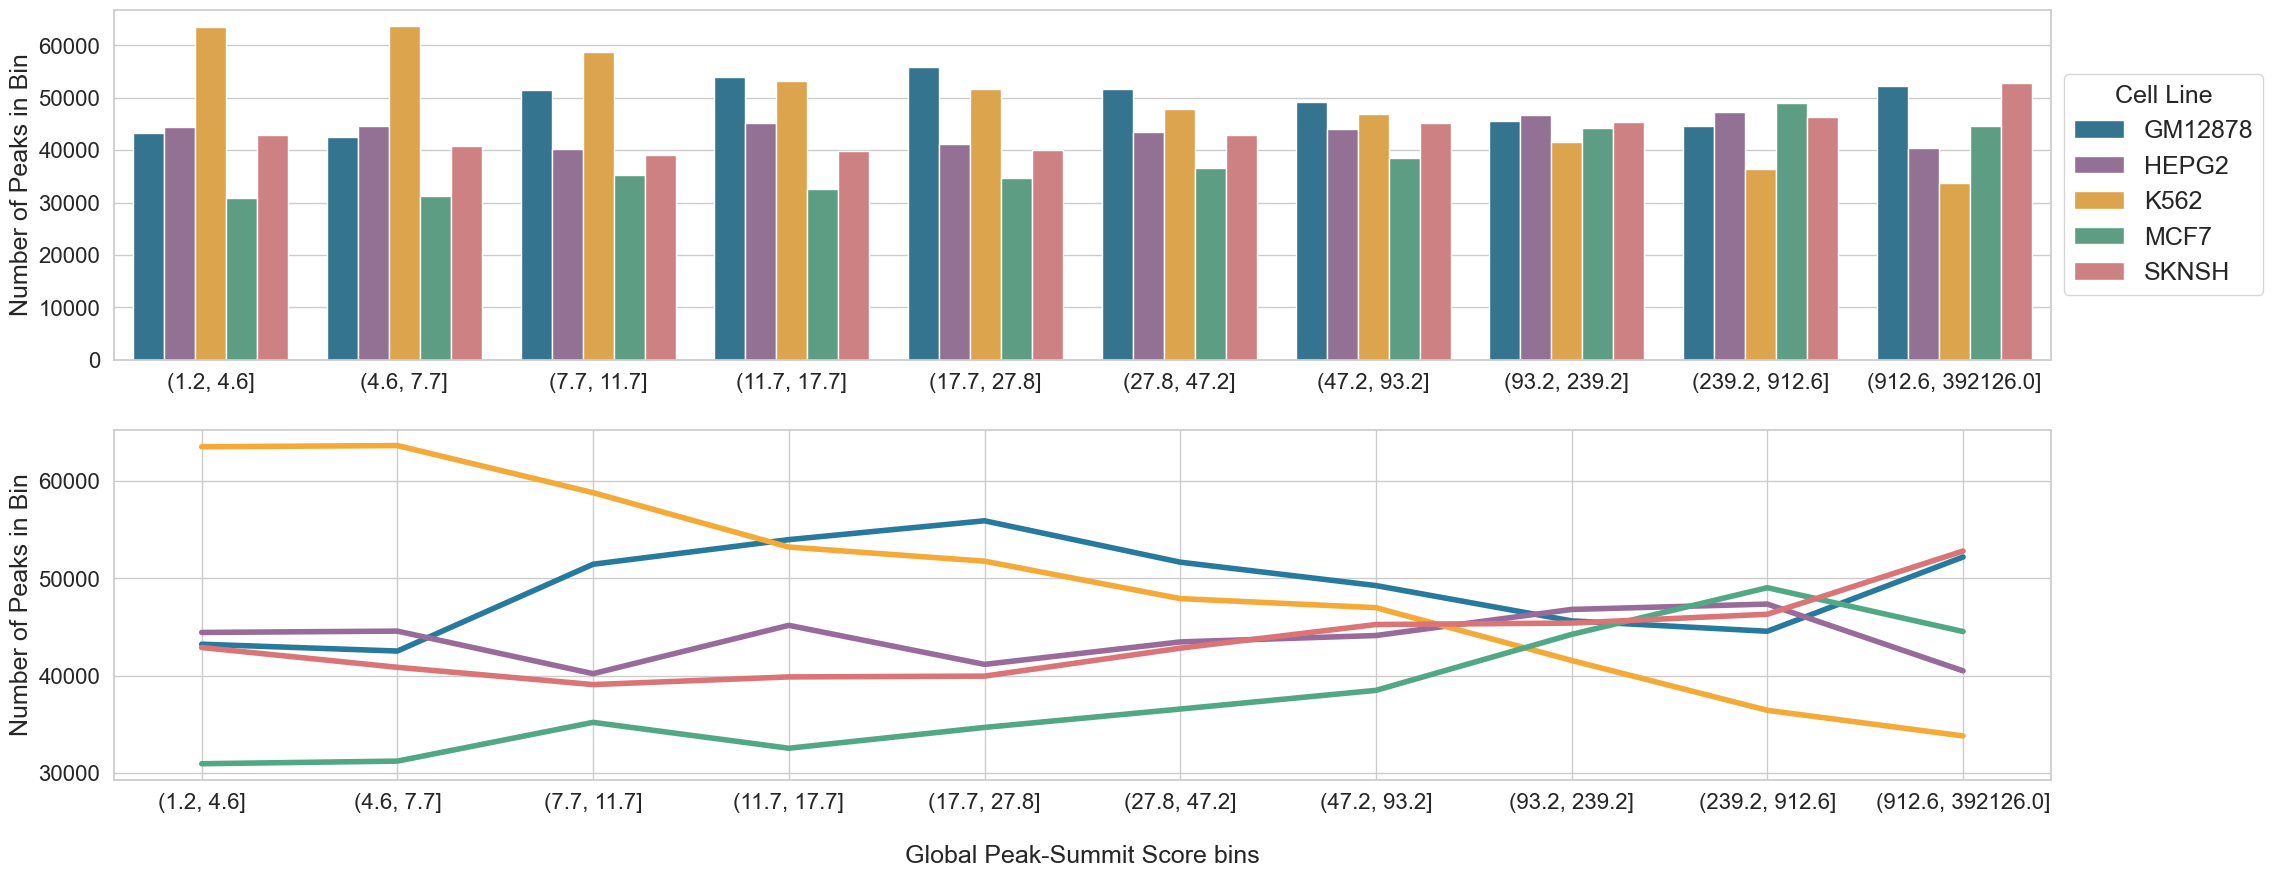

In [16]:
color_scheme_cl = {"GM12878": "#267A9E", "MCF7": "#51A885", "K562":"#F5A936", "SKNSH": "#DB7476", "HEPG2": "#986B9B"}
long_format['qcut_bin2'] = long_format['qcut_bin'].astype(str)

fs2 = 18
fs = 16
fig = plt.figure(figsize=(25, 10))
gs = GridSpec(2, 1, figure=fig, wspace=0.2, hspace=0.2)
sns.set(style = "whitegrid")

ax = fig.add_subplot(gs[0])
sns.barplot(data=long_format, x='qcut_bin', y='count',hue="cell_line", palette=color_scheme_cl)
ax.set_ylabel("Number of Peaks in Bin", fontsize=fs2)
#ax.set_xlabel("Global Peak-Summit Score bins", fontsize=fs2)
ax.set_xlabel("")
ax.legend(numpoints=1, ncol=1, fancybox = True, title_fontsize=fs2,
          fontsize=fs2, loc='center left', title="Cell Line",
          bbox_to_anchor=(1, 0.5)) 
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='x', labelsize=fs)

ax = fig.add_subplot(gs[1])
sns.lineplot(data=long_format, x='qcut_bin2', y='count', hue="cell_line", palette=color_scheme_cl, lw=4)
ax.set_ylabel("Number of Peaks in Bin", fontsize=fs2)
ax.set_xlabel("\nGlobal Peak-Summit Score bins", fontsize=fs2)
ax.get_legend().remove()
ax.tick_params(axis='y', labelsize=fs)
ax.tick_params(axis='x', labelsize=fs)
#ax.legend(numpoints=1, ncol=1, fancybox = True, fontsize='large', loc='center left', bbox_to_anchor=(1, 0.5)) #, bbox_to_anchor=(0.1, 0.1), prop={"size":20})

plt.show()

# 2. Peak calls across downsampling  <a class="anchor" id="second-bullet"></a>


In [17]:
####------------- MAKE INPUT FILE -------------####

def BuildDict(data_dir, cl, fval=0.3):
    def _checkReplicates(df, file, fval):
        pybed_a = pybedtools.BedTool.from_dataframe(df)
        df_sub = pd.read_csv(f"{data_dir}/{file}", sep="\t", header=None)
        pybed_b = pybedtools.BedTool.from_dataframe(df_sub)
        results = pybed_a.intersect(b=pybed_b, s=False, f=fval, r=True, u=True)
        if os.stat(results.fn).st_size == 0:
            return 0
        else:
            val = pd.read_table(results.fn, header=None).shape[0]
            return(val)
        
        
    files = [x for x in os.listdir(data_dir) if cl in x and x.endswith("_filt_500bp.exclusion.bed")]
    #print(files)
    
    reference = f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed"
    df_reference = pd.read_csv(reference, sep="\t", header=None)
    pybed_a = pybedtools.BedTool.from_dataframe(df_reference)
    #display(df_reference)
        
    conds = [i.split('_')[1] for i in files]
    
    output_dict = {'baseline':[df_reference.shape[0], df_reference.shape[0], 0, 0, 0, fval, cl]}
    for group in np.unique(conds):
        replist = [i for i in files if f"_{group}_" in i]

        for rep in replist:
            rep_name = re.sub('_filt_500bp.exclusion.bed', '', rep)
            df_sub = pd.read_csv(f"{data_dir}/{rep}", sep="\t", header=None)
            #display(df_sub)
            pybed_b = pybedtools.BedTool.from_dataframe(df_sub)
            results = pybed_a.intersect(b=pybed_b, s=False, f=fval, r=True, u=True)
            results1 = pybed_b.intersect(b=pybed_a, s=False, f=fval, r=True, u=True)
            results2 = pybed_b.intersect(b=pybed_a, s=False, f=fval, r=True, v=True) #u=True,
            not_found_df = pd.read_table(results2.fn, header=None)
            other_files = [x for x in replist if x != rep]

            overlap_list = [_checkReplicates(not_found_df, f, fval) for f in other_files]

            output_dict[rep_name] = [pd.read_table(results.fn, header=None).shape[0],
                           df_sub.shape[0], 
                           pd.read_table(results1.fn, header=None).shape[0],
                           not_found_df.shape[0],
                           np.max(overlap_list),
                           fval,
                           cl]

    return(output_dict)


def main():
    all_outputs = pd.DataFrame()
    for cl in ["HEPG2", "K562", "MCF7", "GM12878", "SKNSH"]:
        for bd in ["02_cells", "03_reads", "04_frip"]:
            odict = BuildDict(data_dir = f"../05_footprinting/{bd}/macs3/",
                               cl=cl, 
                               fval=0.3)

            tmp = pd.DataFrame(odict).T
            tmp["sampling_type"] = bd[3:]
            all_outputs = pd.concat([all_outputs, tmp])
            print(f"Done with {cl}:{bd}")

    all_outputs.to_csv("05_peak_consistency.csv")
    
#main()
### dont rerun! ###

In [50]:
def _quick_update(group):
    cl = group.index[1].split("_")[0]
    tot = group.loc["baseline"]["baseline_peaks_found"]
    group["y"] = (group["baseline_peaks_found"].values/tot)*100
    group["x"] = "baseline"
    s_names = [i.split("_")[1] for i in group.index if i != "baseline"]
    s_names = [i[1:] for i in s_names]
    group.loc[group.index != "baseline", "x"] = s_names
    
    group["unique"] = group["total_peaks"] - (group["peaks_in_baseline"] + group["peaks_found_inreps"])
    group.loc[["baseline"], "unique"] = 0
    group.loc[["baseline"], "peaks_in_baseline"] = group.loc[["baseline"], "total_peaks"]
    #group = toplot[["x", "peaks_in_baseline","peaks_found_inreps", "unique"]]
    return group
    

def _sort_df(df, st, cl=None):
    if cl is None: toplot = df[df["sampling_type"]==st]
    else: toplot = df[(df["sampling_type"]==st) & (df["cell_line"]==cl)]
    
    toplot = toplot[["x", "peaks_in_baseline","peaks_found_inreps", "unique"]]
    
    if st == "frip": toplot["x"] = [f"0.{i[1:]}" if i != "baseline" else i for i in toplot["x"]]
    toplot["x_numeric"] = pd.to_numeric(toplot["x"], errors="coerce")  # Converts non-numeric values to NaN

    # Sort using the numeric column, and put 'baseline' at the end
    df_sorted = toplot.sort_values(
        by=["x_numeric"], 
        key=lambda col: col.fillna(float("inf")),  # Replace NaN with a high value for sorting
        ascending=False
    ).drop(columns="x_numeric")  # Remove helper column if not needed

    df_sorted.index = df_sorted.x
    return df_sorted
    

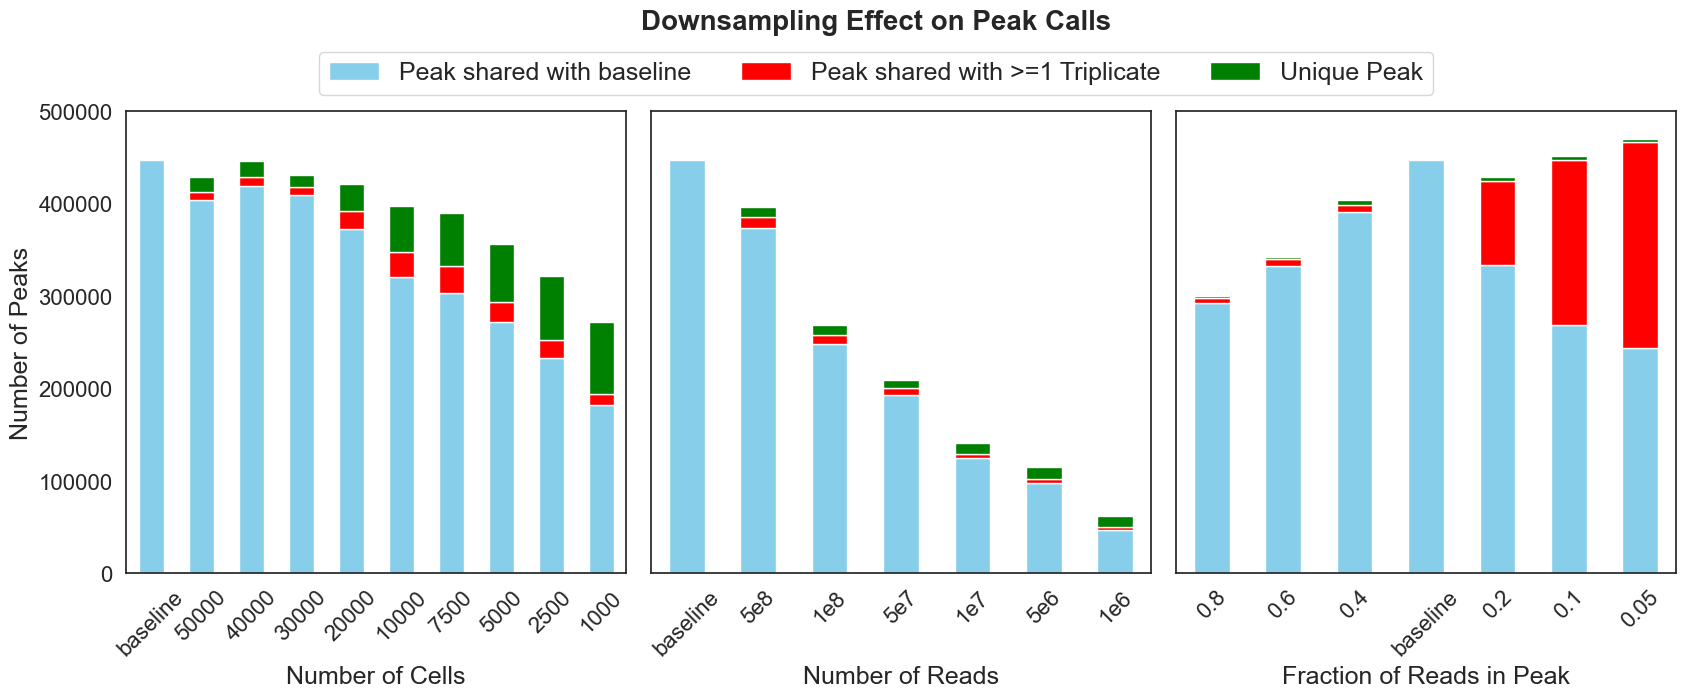

In [51]:
df = pd.read_csv("05_peak_consistency.csv", 
                names = ["baseline_peaks_found", "total_peaks", "peaks_in_baseline", "peaks_notin_baseline", "peaks_found_inreps", "overlap_required", "cell_line","sampling_type"],
                header=0)

df1 = df.groupby(["sampling_type", "cell_line"]).apply(_quick_update, include_groups=False)
df1 = df1.groupby(["sampling_type", "x"], as_index=True)[["peaks_in_baseline","peaks_found_inreps", "unique"]].mean()
df1.reset_index(inplace=True)


fig, axes = plt.subplots(1, 3, figsize=(20,6))
sns.set(style = "white")
fs = 16
fs2=18

axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.05) 

for i, st in enumerate(["cells", "reads", "frip"]):
    ax = axes[i]
    df_sorted = _sort_df(df1, st, None)
    if st == "frip":
        df_sorted = df_sorted.reindex(['0.8', '0.6', '0.4', "baseline", '0.2', '0.1', '0.05'])
    df_sorted.plot(kind="bar", stacked=True, color=["skyblue", "red", "green"], ax=ax)
    ax.tick_params(axis='x', labelrotation=45)
    ax.set_xlabel("")
    
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()
    
    ax.set_ylim(0, 500000)
    ax.tick_params(axis='x', labelsize=fs)

    if i !=0:
       ax.set_yticks([])
       ax.set_ylabel("")
    else:
       ax.set_ylabel("Number of Peaks", fontsize=fs2)
        
labels=["Peak shared with baseline", "Peak shared with >=1 Triplicate", "Unique Peak"]
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1), ncol=3, prop={"size":fs2}) 

ax = axes[0]
ax.set_xlabel("Number of Cells", fontsize=fs2)
ax.tick_params(axis='y', labelsize=fs)

ax = axes[1]
ax.set_xlabel("Number of Reads", fontsize=fs2)

ax = axes[2]
ax.set_xlabel("Fraction of Reads in Peak", fontsize=fs2)

fig.suptitle("Downsampling Effect on Peak Calls", weight="bold",
             fontsize=20, x=0.5, y=1.05, horizontalalignment='center')


plt.show()



# 3. Predictors of sample-F1 scores <a class="anchor" id="third-bullet"></a>

In [114]:
####------------- GATHER PEAK COVERAGE PER CELL LINE -------------####

import multiprocessing as mp
from functools import partial
import pyBigWig

def mean_cov(row, bw):
    coverage = bw.stats(row["chr"], row["start"], row["stop"], type="mean")
    return coverage[0] if coverage else 0

def process_chunk(f, peak_df):
    print(f)
    with pyBigWig.open(f) as bw:
        res = peak_df.apply(lambda row: mean_cov(row, bw), axis=1)  # Ensure bw is passed correctly
    return res


def GetMeanCoverage(cl, nproc=4):

    data_dir = "../06_dataquality/tfbs_universe/bigwigs/"

    peak_df=pd.read_csv(f"../03_peakcalls/{cl}_filt_500bp.exclusion.bed.gz", sep="\t", 
                header=None, index_col = False, 
                names=["chr","start","stop","peakname", "summit_score", "strand"])
    peak_df["region_atac"] = peak_df["chr"].astype(str) + ":" + peak_df["start"].astype(str) + "-" + peak_df["stop"].astype(str)

    files = [f"{data_dir}/{x}" for x in os.listdir(data_dir) if cl in x]

    with mp.Pool(processes=nproc) as pool:
        results = pool.map(partial(process_chunk, peak_df=peak_df), files)

    df = pd.concat(results, axis=1)
    df.columns = [re.sub(".bw" , "", os.path.basename(x)) for x in files]
    df["summit_score"] = peak_df["summit_score"]
    df.index = peak_df["region_atac"]
    
    df.to_csv(f"../06_dataquality/tfbs_universe/PeakCoverage_{cl}.csv")
    return df


def main():
    for cl in ["HEPG2", "MCF7", "K562", "SKNSH", "GM12878"]:
        df = GetMeanCoverage(cl, 10)
    print("done")

#main()
### dont rerun! ###

In [81]:
####------------- LOAD FILES FROM ABOVE -------------####

all_dfs = []
for cl in ["HEPG2", "K562", "MCF7", "SKNSH"]: #GM12878 seems unfair to TOBIAS, removing from this analysis section 
    
    peak_df = pd.read_csv(f"../06_dataquality/tfbs_universe/PeakCoverage_{cl}.csv.gz", index_col=0)
    column_means = pd.DataFrame(peak_df.mean())
    column_means.columns = ["PeakCoverage"]
    
    for tool in ["hint", "print", "tobias"]:
        if tool == "hint":
            data_dir = f"../06_dataquality/{tool}/metrics/no_threshold/"
        elif tool == "tobias":
            data_dir = f"../06_dataquality/{tool}/metrics/bound_threshold/"
        elif tool == "print":
            data_dir = f"../06_dataquality/{tool}/metrics/thresh_03/"

        df = pd.read_csv(f"{data_dir}/{cl}_bytf.csv", sep=",", index_col=0)
        df = df[df["by"] == "file"]
        merged_df = pd.merge(df, column_means, left_index=True, right_index=True)
        merged_df["tool"] = tool
        merged_df.loc[cl, "cell_line"] = cl #fix dumb error on baseline sample names. 
        all_dfs.append(merged_df)
        
metric_df = pd.concat(all_dfs)
display(metric_df)

,precision_micro,recall_micro,f1_micro,precision_mean,recall_mean,f1_mean,precision_sd,recall_sd,f1_sd,FRIP,...,Nnonpeakpairs,Npeakpairs,Nreadpairs,sampling_type,seed,value,cell_line,by,PeakCoverage,tool
HEPG2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.287,...,454695021.0,183458731.0,638153752.0,baseline,NaN,NaN,HEPG2,file,410.263319,hint
HEPG2_c10000_s46,0.433525,0.447681,0.440489,0.419578,0.431021,0.425160,0.056260,0.054548,0.055220,0.288,...,181415909.0,73401930.0,254817839.0,cells,46.0,10000.0,HEPG2,file,164.009212,hint
HEPG2_c10000_s5,0.435599,0.450496,0.442922,0.421935,0.433704,0.427675,0.056253,0.055049,0.055460,0.288,...,181735501.0,73426966.0,255162467.0,cells,5.0,10000.0,HEPG2,file,163.572002,hint
HEPG2_c10000_s65,0.432750,0.447615,0.440057,0.418147,0.430247,0.424044,0.056806,0.055138,0.055784,0.287,...,180265553.0,72733610.0,252999163.0,cells,65.0,10000.0,HEPG2,file,162.526890,hint
HEPG2_c1000_s42,0.275323,0.205386,0.235267,0.255942,0.189862,0.217817,0.056069,0.044996,0.049398,0.286,...,17959466.0,7176596.0,25136062.0,cells,42.0,1000.0,HEPG2,file,16.008358,hint
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SKNSH_r5e7_s41,0.506767,0.999111,0.672453,0.468043,0.998603,0.632603,0.089504,0.001208,0.078934,0.291,...,35444755.0,14555245.0,50000000.0,reads,41.0,50000000.0,SKNSH,file,33.823466,tobias
SKNSH_r5e7_s42,0.510374,0.999089,0.675617,0.471179,0.998632,0.635488,0.089987,0.001080,0.079044,0.291,...,35436583.0,14563417.0,50000000.0,reads,42.0,50000000.0,SKNSH,file,33.830362,tobias
SKNSH_r5e8_s14,0.993906,0.942201,0.967363,0.992422,0.930052,0.960131,0.003077,0.020778,0.012250,0.287,...,356351682.0,143648318.0,500000000.0,reads,14.0,500000000.0,SKNSH,file,336.541805,tobias
SKNSH_r5e8_s32,0.995030,0.938613,0.965999,0.993671,0.925128,0.958061,0.002766,0.022338,0.013060,0.287,...,356370695.0,143629305.0,500000000.0,reads,32.0,500000000.0,SKNSH,file,336.533714,tobias


In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

results = []
allmetrics = ["PeakCoverage", 'FRIP', 'Ncells', 'Nnonpeakpairs', 'Npeakpairs', 'Nreadpairs']

for i, tool in enumerate(["hint", "tobias", "print"]):
    subset = metric_df[metric_df["tool"] == tool]
    for val in allmetrics:
        X = subset[[val]].values
        Y = subset['f1_mean'].values

        poly = PolynomialFeatures(2)
        X_poly = poly.fit_transform(X)
        model = LinearRegression().fit(X_poly, Y)
        Y_pred = model.predict(X_poly)

        r2 = r2_score(Y, Y_pred)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred))
        results.append([tool, val, r2, rmse])
    
# Show results
df_results = pd.DataFrame(results, columns=['tool', 'group', 'R^2', 'RMSE'])
display(df_results.sort_values("R^2", ascending=False)[:15])

,tool,group,R^2,RMSE
0,hint,PeakCoverage,0.905014,0.073554
12,print,PeakCoverage,0.880769,0.103807
5,hint,Nreadpairs,0.868219,0.086637
17,print,Nreadpairs,0.857038,0.113668
16,print,Npeakpairs,0.799344,0.134665
4,hint,Npeakpairs,0.782821,0.111221
3,hint,Nnonpeakpairs,0.757392,0.117552
15,print,Nnonpeakpairs,0.749579,0.150441
9,tobias,Nnonpeakpairs,0.502189,0.149678
10,tobias,Npeakpairs,0.463311,0.155413


In [83]:
results = []
allmetrics = ['FRIP', 'Ncells', 'Nnonpeakpairs', 'Npeakpairs', 'Nreadpairs']

for i, tool in enumerate(["hint", "tobias", "print"]):
    subset = metric_df[metric_df["tool"] == tool]
    for val in allmetrics:
        X = subset[[val, "PeakCoverage"]].values
        Y = subset['f1_mean'].values

        poly = PolynomialFeatures(2)
        X_poly = poly.fit_transform(X)
        model = LinearRegression().fit(X_poly, Y)
        Y_pred = model.predict(X_poly)

        r2 = r2_score(Y, Y_pred)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred))
        results.append([tool, "peak-coverage+"+val, r2, rmse])
    
# Show results
df_results = pd.DataFrame(results, columns=['Tool', 'Metric', 'R^2', 'RMSE'])
display(df_results.sort_values("R^2", ascending=False)[:15])

,Tool,Metric,R^2,RMSE
1,hint,peak-coverage+Ncells,0.916533,0.068950
0,hint,peak-coverage+FRIP,0.908329,0.072259
3,hint,peak-coverage+Npeakpairs,0.908253,0.072289
11,print,peak-coverage+Ncells,0.897304,0.096340
13,print,peak-coverage+Npeakpairs,0.895843,0.097023
4,hint,peak-coverage+Nreadpairs,0.892778,0.078148
10,print,peak-coverage+FRIP,0.891423,0.099060
14,print,peak-coverage+Nreadpairs,0.875092,0.106249
2,hint,peak-coverage+Nnonpeakpairs,0.856931,0.090272
12,print,peak-coverage+Nnonpeakpairs,0.811043,0.130681


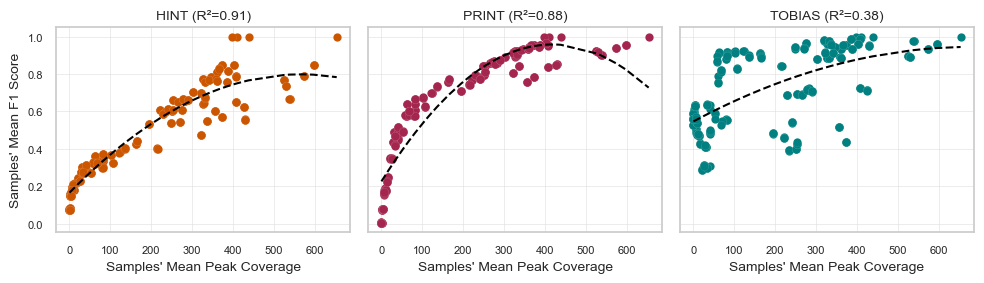

In [84]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
results = []

fs = 8
fs2 = 10
for i, tool in enumerate(["hint", "print", "tobias"]):
    subset = metric_df[metric_df["tool"] == tool]
    X = subset[['PeakCoverage']].values
    Y = subset['f1_mean'].values
    
    #Linear
    #model = LinearRegression().fit(X, Y)
    #Y_pred = model.predict(X)
    
    #curve
    poly = PolynomialFeatures(2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, Y)
    Y_pred = model.predict(X_poly)
    
    #results
    r2 = r2_score(Y, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    results.append([tool, r2, rmse])
    
    #Plot
    sns.set(font_scale=1, style='whitegrid')
    sns.scatterplot(x=X.flatten(), y=Y, ax=axes[i], color=color_scheme_prog[tool], linewidth=0.05)
    X_sorted = np.sort(X, axis=0)
    X_poly_sorted = poly.transform(np.sort(X, axis=0))
    Y_sorted_pred = model.predict(X_poly_sorted)
    axes[i].plot(X_sorted, Y_sorted_pred, color='black', linestyle="dashed")
    axes[i].set_title(f"{tool.upper()} (R²={r2:.2f})", fontsize=fs2)
    #axes[i].legend()
    axes[i].set_ylabel("Samples' Mean F1 Score", fontsize=fs2)
    axes[i].set_xlabel("Samples' Mean Peak Coverage", fontsize=fs2)
    axes[i].tick_params(axis='x', labelsize=fs)
    axes[i].tick_params(axis='y', labelsize=fs)
    axes[i].grid(which='major', color='#DDDDDD', linewidth=0.4)

plt.tight_layout()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


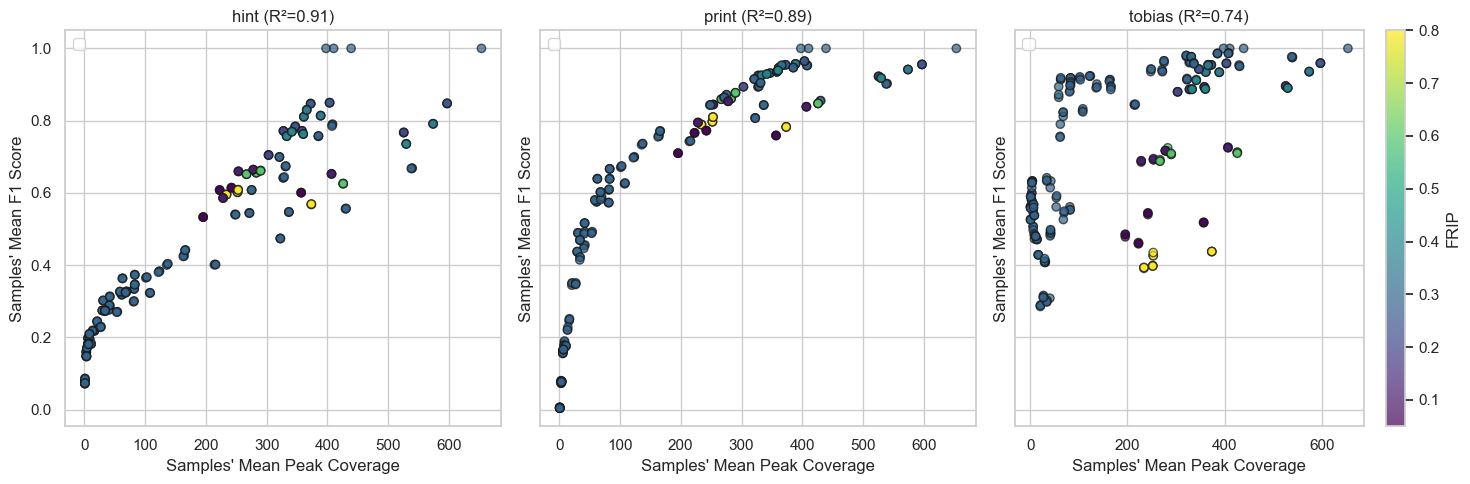

     Tool       R^2      RMSE
0    hint  0.908329  0.072259
1   print  0.891423  0.099060
2  tobias  0.743664  0.107407


In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
results = []

for i, tool in enumerate(["hint", "print", "tobias"]):
    subset = metric_df[metric_df["tool"] == tool]
    X = subset[['PeakCoverage', "FRIP"]].values
    Y = subset['f1_mean'].values

    #curve
    poly = PolynomialFeatures(2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, Y)
    Y_pred = model.predict(X_poly)
    
    #results
    r2 = r2_score(Y, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    results.append([tool, r2, rmse])
    
    #Plot
    sc = axes[i].scatter(x=subset['PeakCoverage'], y=Y, c = subset['FRIP'],
                    cmap='viridis', edgecolor='k', alpha=0.7)
    if i == 2:
        fig.colorbar(sc, ax=axes[i], label="FRIP")
    axes[i].set_title(f"{tool} (R²={r2:.2f})")
    axes[i].legend()
    axes[i].set_ylabel("Samples' Mean F1 Score")
    axes[i].set_xlabel("Samples' Mean Peak Coverage")

plt.tight_layout()
plt.show()

# Show results
df_results = pd.DataFrame(results, columns=['Tool', 'R^2', 'RMSE'])
print(df_results)

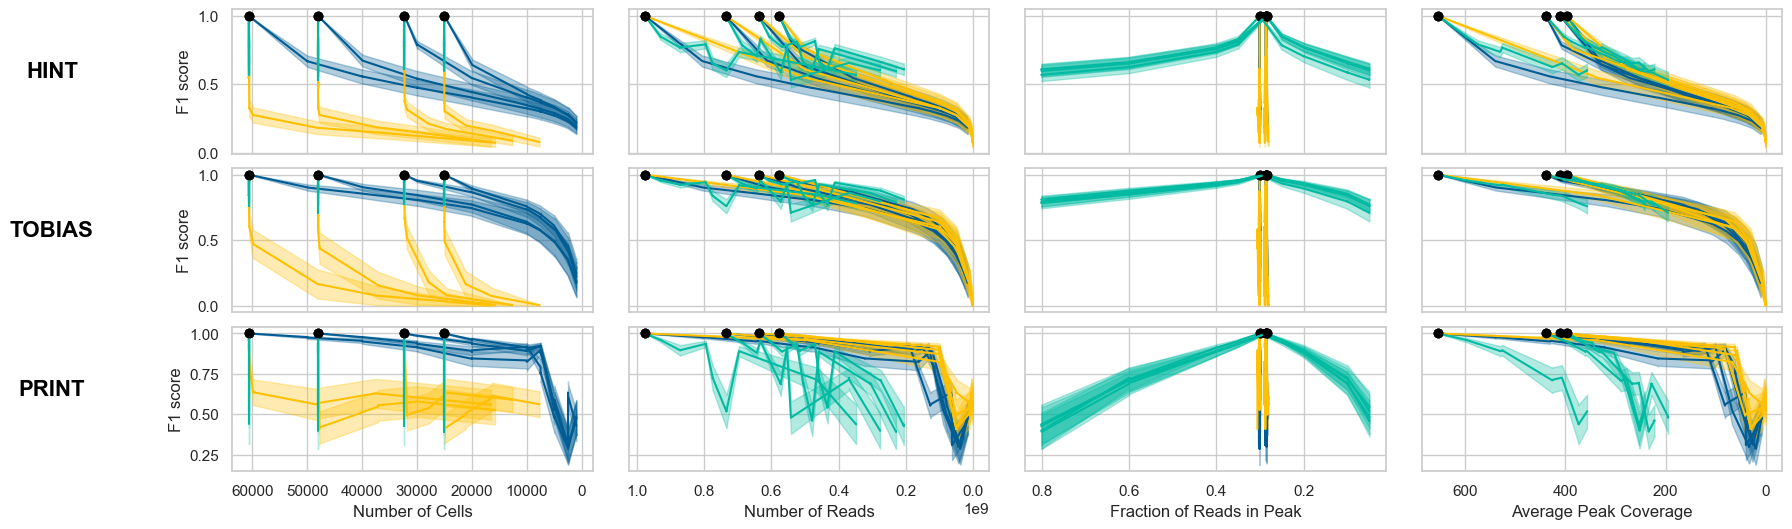

In [86]:
def baseplot(ax0, df, baseline=True, metric="f1", color="black", ls="solid", line_label=" ", pwm=False, lw=2, error_on=True):
    
    obj = zip(df["x"].to_list(),
              df[f"{metric}_mean"].to_list(),
              df[f"{metric}_sd"].to_list())
    myx, myy, mye = zip(*sorted(obj))
    ax0.plot(myx, myy, linestyle=ls, marker="o", linewidth=lw, markersize=6, color=color, label=line_label)
    if error_on: ax0.errorbar(myx, myy, yerr=mye, fmt='',linewidth=lw, color=color, linestyle=ls)

    if baseline:
        obj = zip(df[df.sampling_type == "baseline"]["x"].to_list(),
                  df[df.sampling_type == "baseline"][f"{metric}_mean"].to_list())
        myx, myy = zip(*sorted(obj))
        ax0.plot(myx, myy, linestyle=ls, marker="*", linewidth=lw, markersize=14, color="black")

    ax0.set_ylim(ymin=0, ymax=1.1)
    ax0.set_ylabel(metric)
    ax0.set_xlabel("")
    ax0.get_legend().remove()

    return ax0
    
ncol=4
fig, axes = plt.subplots(3, ncol, figsize=(20,6))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set(font_scale=1, style='whitegrid')

for i, tool in enumerate(["hint", "print", "tobias"]):
    for j, xaxis in enumerate(["Ncells" , "Nreadpairs", "FRIP", "PeakCoverage"]):
        k = (i * ncol)+j
        ax0 = axes[k]
        for st in ["cells", "reads", "frip"]:
            for cl in ["HEPG2", "K562", "MCF7", "SKNSH"]:
                curr_df = metric_df[(metric_df["tool"] == tool) & 
                                     (metric_df["sampling_type"].isin([st, "baseline"])) &
                                     (metric_df["cell_line"] == cl)].copy()
                curr_df = curr_df.sort_values(xaxis)
                
                #### fill version ###
                ax0.plot(curr_df[xaxis], curr_df["f1_mean"], label=st, color=color_scheme_st[st], marker="")
                ax0.fill_between(curr_df[xaxis], 
                                 curr_df["f1_mean"] - curr_df["f1_sd"], 
                                 curr_df["f1_mean"] + curr_df["f1_sd"], 
                                 color=color_scheme_st[st], alpha=0.3, label="Spread (± SD)")
                curr_df1 = curr_df[curr_df["sampling_type"] == "baseline"]
                ax0.plot(curr_df1[xaxis], curr_df1["f1_mean"], color="black", marker="o")
                
        ax0.invert_xaxis()
        if k not in [0,ncol,ncol*2]:
            ax0.set_ylabel(""); ax0.set_yticklabels([])
        if k in range(0,ncol*2):
            ax0.set_xlabel(""); ax0.set_xticklabels([])
        
ax0 = axes[(ncol*2)+0]; ax0.set_xlabel("Number of Cells")
ax0 = axes[(ncol*2)+1]; ax0.set_xlabel("Number of Reads")
ax0 = axes[(ncol*2)+2]; ax0.set_xlabel("Fraction of Reads in Peak")
ax0 = axes[(ncol*2)+3]; ax0.set_xlabel("Average Peak Coverage")

ax0 = axes[0]; ax0.text(-0.5, 0.5, "HINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=16, color='black', weight='bold')
ax0 = axes[0]; ax0.set_ylabel("F1 score")
ax0 = axes[ncol]; ax0.text(-0.5, 0.5, "TOBIAS", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=16, color='black', weight='bold')
ax0 = axes[ncol]; ax0.set_ylabel("F1 score")
ax0 = axes[ncol*2]; ax0.text(-0.5, 0.5, "PRINT", va='bottom', ha='center', rotation='horizontal', transform=ax0.transAxes, fontsize=16, color='black', weight='bold')
ax0 = axes[ncol*2]; ax0.set_ylabel("F1 score")

plt.show()

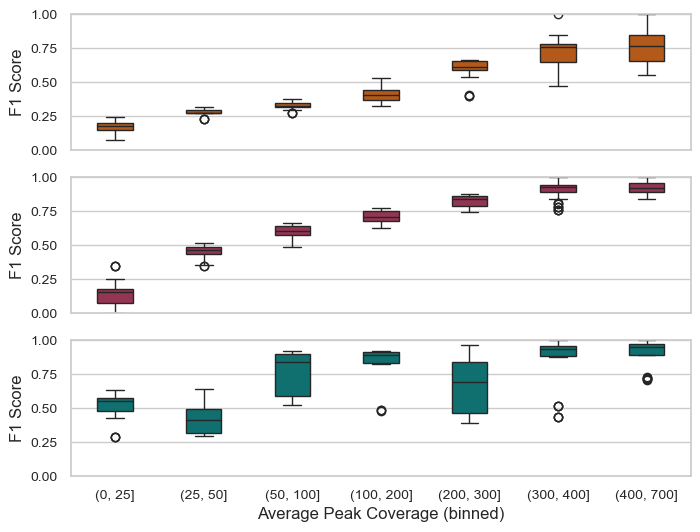

In [87]:
fig = plt.figure(figsize=(8,6))
gs = GridSpec(3, 1, figure=fig, wspace=0.2, hspace=0.2)
sns.set(font_scale=1, style='whitegrid')

bins = [0, 25, 50, 100, 200, 300, 400, 700]
boxplot_df2['bin'] = pd.cut(boxplot_df2["PeakCoverage"], bins=bins)

for i, tool in enumerate(["hint", "print","tobias"]):
    ax = fig.add_subplot(gs[i])
    sns.boxplot(x="bin",
                y="f1_mean",
                data=boxplot_df2[boxplot_df2["tool"] == tool],
                hue="tool",
                palette=color_scheme_prog,
                width=0.4, ax=ax)
   
    ax.set_ylim(0,1)
    ax.get_legend().remove()
    ax.tick_params(axis='y', labelsize=10)
    ax.set_ylabel("F1 Score")
    if i ==2:
        ax.tick_params(axis='x', labelsize=10)
        ax.set_xlabel("Average Peak Coverage (binned)")
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    
plt.show()

# 4. Per TFBS F1 scores by read-coverage <a class="anchor" id="fourth-bullet"></a>


- Are low coverage regions causing FPs or FNs?


- What is causing each? 

- What is about certain peak regions that cause high FPs or FNs? 
- FNs can likely be predicted by coverage. 
- Are false positives as well? 

In [101]:
####------------- GET F1 scores PER TFBS -------------####

def BuildPeak_x_Scores(cl, tool):

    def _make_contingency_table(df_observed, df_expected): 
        contingency_table = {
                'TP': np.sum(np.minimum(df_observed, df_expected), axis=1),  # Minimum of the two values is true positive
                'FP': np.sum(np.maximum(0, df_observed - df_expected), axis=1),  # Difference, where df_observed > df_expected
                'FN': np.sum(np.maximum(0, df_expected - df_observed), axis=1),  # Difference, where df_expected > df_observed
                'TN': np.sum((df_observed == 0) & (df_expected == 0), axis=1)
            }
        contingency_df = pd.DataFrame(contingency_table)
        return(contingency_df)

    
    def _calc_scores(df):

        df['precision'] = np.where(df['TP'] + df['FP'] == 0, np.nan, 
                                   df['TP'] / (df['TP'] + df['FP']))
        df['recall']    = np.where(df['TP'] + df['FN'] == 0, np.nan, 
                                   df['TP'] / (df['TP'] + df['FN']))
        df['f1']        = np.where(df['TP'] + (0.5 * (df['FP'] + df['FN'])) == 0, np.nan,
                                   df['TP'] / (df['TP'] + (0.5 * (df['FP'] + df['FN']))))
        df['fpr']       = np.where(df['FP'] + df['TN'] == 0, np.nan, 
                                   df['FP'] / (df['FP'] + df['TN']))

        return(df)

    
    #Load in the baseline matrix
    data_dir = f"../06_dataquality/{tool}/mats/"
    out_dir = f"../06_dataquality/tfbs_universe/metrics/{tool}/"
    
    baseline=f"{cl}-cellFilt.mat"
    df_baseline = pd.read_csv(f"{data_dir}/{baseline}", sep=",", index_col=0)

    #Load in the peak matrix
    peak_df= pd.read_csv(f"../06_dataquality/tfbs_universe/PeakCoverage_{cl}.csv.gz")
    
    #Get all files
    files1 = [x for x in os.listdir(data_dir) if cl in x and x.endswith(".mat") ]
    files = [x for x in files1 if "_p" not in x ]
    for f in files:
        name = re.sub(".mat|-cellFilt" , "", f)
        if os.path.exists(f"{out_dir}/{name}.csv"):
            continue
        else:
            print(name)
        df_comp = pd.read_csv(f"{data_dir}/{f}", sep=",", index_col=0)
        df_comp.index.name  = "region_atac"
        
        if not (df_baseline.columns == df_comp.columns).all(): raise TypeError("Columns not in right order - how?")
        if not (df_baseline.index == df_comp.index).all(): raise TypeError("Rows not in right order - how?")
        
        tmp = _make_contingency_table(df_comp, df_baseline)
        tmp.loc[:,"total_TFBS"] = df_comp.sum(axis=1)
        tmp = _calc_scores(tmp)
        tmp = tmp.merge(peak_df[["region_atac", name]], on='region_atac', how='outer')
        tmp.to_csv(f"{out_dir}/{name}.csv")
    
    return


def main():
    for cl in ["HEPG2", "MCF7", "K562", "SKNSH"]:
        for tool in ["hint", "tobias", "print"]:
            BuildPeak_x_Scores(cl, tool)
        print("done")

#main()
### requires mat/ files to run -- go download them! ###

In [ ]:
####------------- Combine per-dataset info into single files -------------####

def quickrun(tool, cl):
    data_dir = f"../../06_dataquality/tfbs_universe/metrics/{tool}"
    files = [x for x in os.listdir(data_dir) if x.endswith(".csv") and cl in x]
    files.remove(f"{cl}.csv")

    data_list = []
    for f in files:
        name = re.sub(f".csv", "", f)
        df = pd.read_csv(f"{data_dir}/{f}", sep=",", index_col=0)
        df["fnr"] = df["FN"]/(df["FN"]+ df["FP"])
        df = df[[name, "f1", "precision", "recall", "fpr", "fnr"]]
        df.columns = ["peak_coverage", "f1", "precision", "recall", "fpr", "fnr"]
        data_list.append(df)

    df_all = pd.concat(data_list, ignore_index=True)
    return df_all


df_hint = quickrun("hint", cl)
df_tobias = quickrun("tobias", cl)
df_print = quickrun("print", cl)
display(df_hint)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

(0, 100] vs. (100, 100000]: t-test independent samples, P_val:0.000e+00 t=-3.167e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

(0, 100] vs. (100, 100000]: t-test independent samples, P_val:0.000e+00 t=-4.056e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

(0, 100] vs. (100, 100000]: t-test independent samples, P_val:0.000e+00 t=-2.181e+03


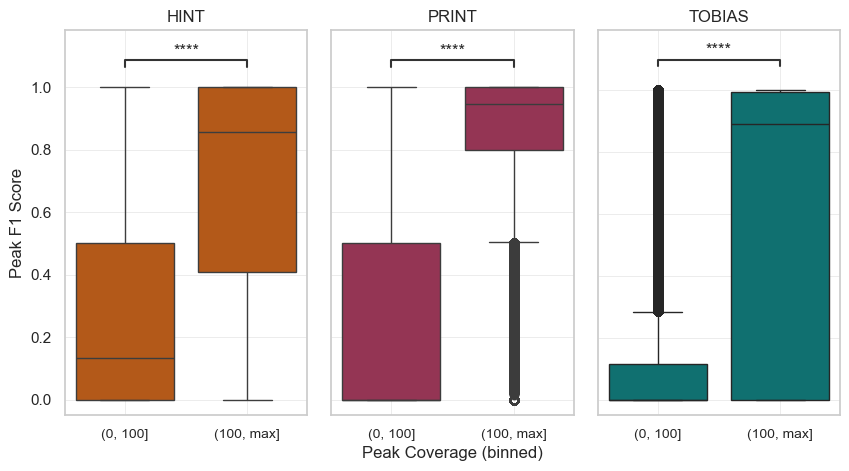

In [90]:
from statannotations.Annotator import Annotator

def _boxplotAnnotated(df, ax, pairs, xlabels=None, color="grey"):
    ax = sns.boxplot(x='peak_coverage_bin', y="f1", data=df, color=color)
    ax.set_xlabel("")
    ax.set_ylabel("Peak F1 Score")
    
    df["bin_str"] = df["peak_coverage_bin"].astype(str)
    annotator = Annotator(ax, pairs, data=df, x='bin_str', y='f1')
    annotator.configure(test="t-test_ind", text_format="star", loc="inside")
    annotator.apply_and_annotate()

    if xlabels != None:
        ax.tick_params(axis='x', labelsize=10)
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(xlabels)

    ax.grid(which='major', color='#DDDDDD', linewidth=0.4)
    return ax


fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 3, figure=fig, wspace=0.1, hspace=0.1)

df_hint["peak_coverage_bin"] = pd.cut(df_hint["peak_coverage"], bins=[0,100,100000])
df_tobias["peak_coverage_bin"] = pd.cut(df_tobias["peak_coverage"], bins=[0,100,100000])
df_print["peak_coverage_bin"] = pd.cut(df_print["peak_coverage"], bins=[0,100,100000])
p = [('(0, 100]', '(100, 100000]')]
xl = ['(0, 100]', '(100, max]']

ax0 = fig.add_subplot(gs[0])
ax0 = _boxplotAnnotated(df=df_hint, 
                  ax=ax0, 
                  pairs=p,
                  xlabels=xl,
                  color=color_scheme_prog["hint"])
ax0.set_title("HINT")

ax1 = fig.add_subplot(gs[1])
ax1 = _boxplotAnnotated(df=df_print, 
                  ax=ax1, 
                  pairs=p,
                  xlabels=xl,
                  color=color_scheme_prog["print"])
ax1.set_yticklabels("")
ax1.set_ylabel("")
ax1.set_title("PRINT")
ax1.set_xlabel("Peak Coverage (binned)")

ax2 = fig.add_subplot(gs[2])
ax2 = _boxplotAnnotated(df=df_tobias, 
                  ax=ax2, 
                  pairs=p,
                  xlabels=xl,
                  color=color_scheme_prog["tobias"])
ax2.set_yticklabels("")
ax2.set_ylabel("")
ax2.set_title("TOBIAS")

plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

(100, 100000] vs. (0, 50]: t-test independent samples, P_val:0.000e+00 t=3.963e+03
(50, 100] vs. (100, 100000]: t-test independent samples, P_val:0.000e+00 t=-1.061e+03
(50, 100] vs. (0, 50]: t-test independent samples, P_val:0.000e+00 t=2.055e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

(100, 100000] vs. (0, 50]: t-test independent samples, P_val:0.000e+00 t=6.037e+03
(50, 100] vs. (100, 100000]: t-test independent samples, P_val:0.000e+00 t=-1.256e+03
(50, 100] vs. (0, 50]: t-test independent samples, P_val:0.000e+00 t=2.964e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p 

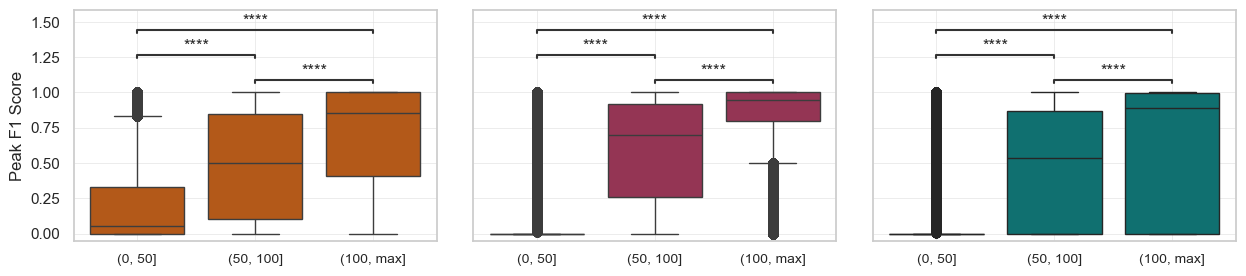

In [91]:
fig = plt.figure(figsize=(15,3))
gs = GridSpec(1, 3, figure=fig, wspace=0.1, hspace=0.1)


df_hint["peak_coverage_bin"] = pd.cut(df_hint["peak_coverage"], bins=[0, 50, 100, 100000])
df_tobias["peak_coverage_bin"] = pd.cut(df_tobias["peak_coverage"], bins=[0, 50, 100, 100000])
df_print["peak_coverage_bin"] = pd.cut(df_print["peak_coverage"], bins=[0, 50, 100, 100000])
p = [('(0, 50]', '(100, 100000]'), ('(0, 50]', '(50, 100]'), ('(50, 100]', '(100, 100000]')]
xl = ['(0, 50]', '(50, 100]', '(100, max]']

ax0 = fig.add_subplot(gs[0])

ax0 = _boxplotAnnotated(df=df_hint, 
                  ax=ax0, 
                  pairs=p,
                  xlabels=xl,
                  color=color_scheme_prog["hint"])

ax1 = fig.add_subplot(gs[1])
ax1 = _boxplotAnnotated(df=df_print, 
                  ax=ax1, 
                  pairs=p,
                  xlabels=xl,
                  color=color_scheme_prog["print"])
ax1.set_yticklabels("")
ax1.set_ylabel("")

ax2 = fig.add_subplot(gs[2])
ax2 = _boxplotAnnotated(df=df_tobias, 
                  ax=ax2, 
                  pairs=p,
                  xlabels=xl,
                  color=color_scheme_prog["tobias"])
ax2.set_yticklabels("")
ax2.set_ylabel("")

plt.show()

# 5. How restrictive is 100 reads? <a class="anchor" id="fifth-bullet"></a>


In [99]:
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csr_matrix

def main():
    alldfs = []
    for cl in ["HEPG2", "K562", "SKNSH", "MCF7"]:
        print(cl)
        df = pd.read_csv(f"../06_dataquality/tfbs_universe/{cl}_mat_long.txt", 
                     header=None, sep=" ", index_col=False, names=["region", "cb", "count"])
        #cellxcount = df.pivot(index='region', columns='cb', values='count', fill=0)
    
        row_idx, unique_peaks = pd.factorize(df["region"])
        col_idx, unique_barcodes = pd.factorize(df["cb"])
        sparse_matrix = sp.csr_matrix((df["count"].values, (row_idx, col_idx)), 
                                      shape=(len(unique_peaks), len(unique_barcodes)))
        print(sparse_matrix.shape)
    
    
        final_dict = {}
        num_rows, num_cols = sparse_matrix.shape
    
        for Ncbs in range(500, num_cols, 1000):
            sampled_cols = np.random.choice(num_cols, Ncbs, replace=False)
            sub_matrix = sparse_matrix[:, sampled_cols]
            row_sums = np.array(sub_matrix.sum(axis=1)).flatten()
            v1 = np.sum(row_sums >= 100)
            v2 = np.sum(row_sums >= 50)
            final_dict[Ncbs] = [v1, v2, (v1/num_rows)*100, (v2/num_rows)*100]
    
        resdf = pd.DataFrame.from_dict(final_dict, orient='index')
        resdf = resdf.reset_index()
        resdf.columns = ["N_cells", "Npeaks_at100", "Npeaks_at50", "%at100", "%at50"]
        resdf["cell_line"] = cl
        alldfs.append(resdf)
        
    df = pd.concat(alldfs)
    df.to_csv(f"../06_dataquality/tfbs_universe/peaks_by_sampling.csv")

#main()
print("done")

done


In [100]:
df = pd.read_csv(f"../06_dataquality/tfbs_universe/peaks_by_sampling.csv.gz", index_col=0) 
display(df)

,N_cells,Npeaks_at100,Npeaks_at50,%at100,%at50,cell_line
0,500,15752,37578,3.684497,8.789744,HEPG2
1,1500,58711,115914,13.732893,27.113054,HEPG2
2,2500,98732,192574,23.094070,45.044337,HEPG2
3,3500,130837,257194,30.603643,60.159384,HEPG2
4,4500,165460,319850,38.702192,74.815038,HEPG2
...,...,...,...,...,...,...
27,27500,366747,366933,99.927523,99.978202,MCF7
28,28500,366766,366934,99.932700,99.978475,MCF7
29,29500,366787,366935,99.938422,99.978747,MCF7
30,30500,366802,366940,99.942509,99.980110,MCF7


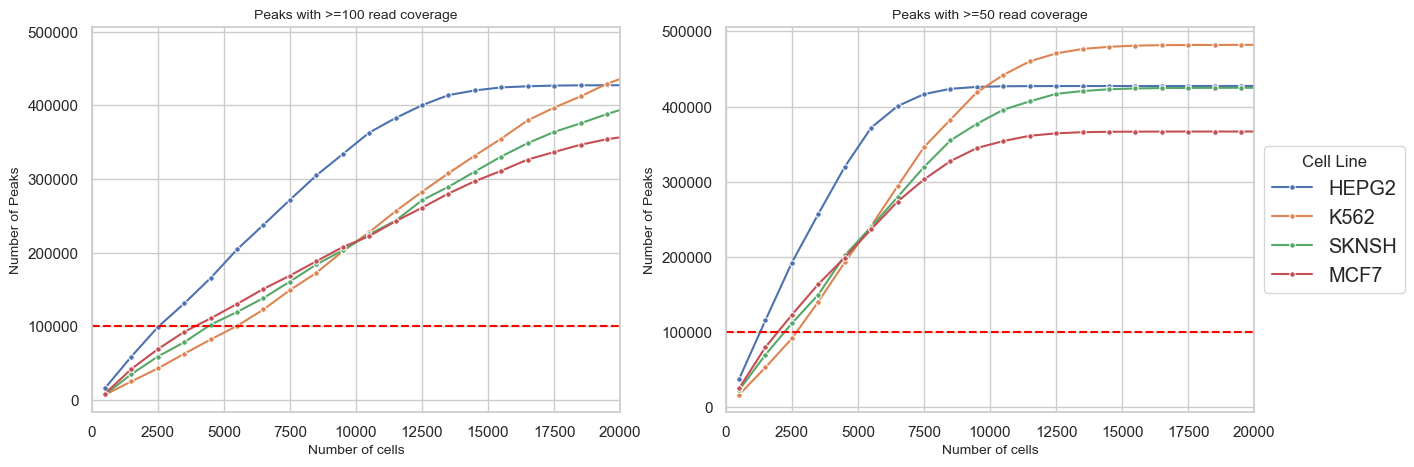

In [97]:
sns.set(style = "whitegrid")
fig = plt.figure(figsize=(15,5))
gs = GridSpec(1, 2, figure=fig)

ax = fig.add_subplot(gs[0])
ax = sns.lineplot(df, x="N_cells", y='Npeaks_at100', hue="cell_line",
                  marker="o", markersize=4)
ax.set_title("Peaks with >=100 read coverage", fontsize=10)
ax.set_ylabel("Number of Peaks", fontsize=10)
ax.set_xlabel("Number of cells", fontsize=10)
ax.axhline(100000, ls='--', color="red")
ax.set_xlim(0, 20000)
ax.get_legend().remove()

ax = fig.add_subplot(gs[1])
ax = sns.lineplot(df, x="N_cells", y='Npeaks_at50', hue="cell_line",
                  marker="o", markersize=4)
ax.set_title("Peaks with >=50 read coverage", fontsize=10)
ax.set_ylabel("Number of Peaks", fontsize=10)
ax.set_xlabel("Number of cells", fontsize=10)
ax.axhline(100000, ls='--', color="red")
ax.set_xlim(0, 20000)
ax.legend(numpoints=1, ncol=1, fancybox = True, title="Cell Line",
          fontsize='large', loc='center left', 
          bbox_to_anchor=(1, 0.5)) #, bbox_to_anchor=(0.1, 0.1), prop={"size":20})
plt.show()

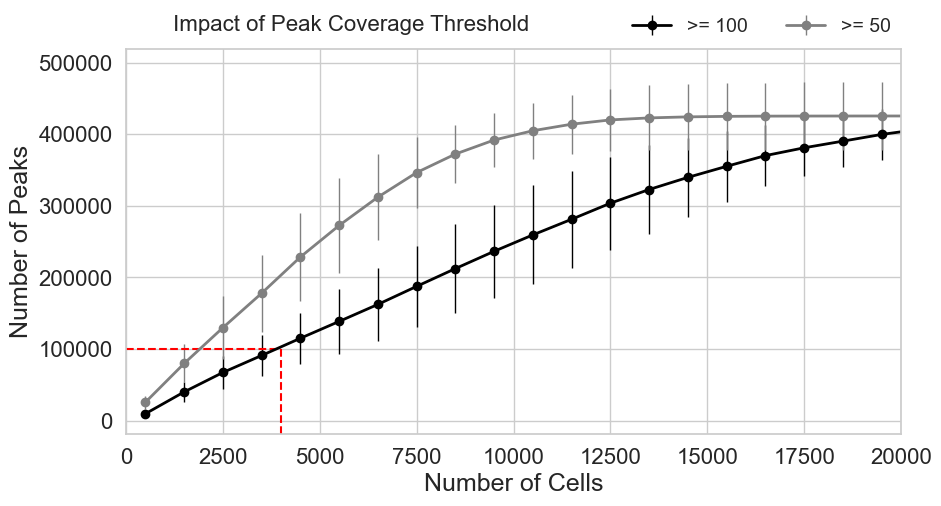

In [98]:
grouped_data = df.groupby('N_cells')[['Npeaks_at100', 'Npeaks_at50']].agg(['mean', 'std'])

fs = 16
fs2=18

sns.set(style = "whitegrid")
fig = plt.figure(figsize=(10,5))
gs = GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0])
ax.errorbar(grouped_data.index, 
            grouped_data[('Npeaks_at100', 'mean')], 
            yerr=grouped_data[('Npeaks_at100', 'std')], 
            linestyle="solid", linewidth=2, elinewidth=1, capsize=0, fmt='o', 
            color='black', label='>= 100')

ax.errorbar(grouped_data.index, 
            grouped_data[('Npeaks_at50', 'mean')], 
            yerr=grouped_data[('Npeaks_at50', 'std')], 
            linestyle="solid", linewidth=2, elinewidth=1, capsize=0, fmt='o', 
            color='grey', label='>= 50')

ax.set_ylabel("Number of Peaks", fontsize=fs2)
ax.set_xlabel("Number of Cells", fontsize=fs2)
ax.axhline(100000, ls='--', color="red",xmax=0.2)
ax.axvline(4000, ls='--', color="red",ymax=0.23)
ax.set_xlim(0, 20000)

ax.tick_params(axis='x', labelsize=fs)
ax.tick_params(axis='y', labelsize=fs)

fig.suptitle("Impact of Peak Coverage Threshold", 
             fontsize=fs, x=0.35, horizontalalignment='center',
              y=0.95)

ax.legend(fontsize=14, title_fontsize=fs,
          loc='lower center',  bbox_to_anchor=(1-0.18, 0.99), ncol=2, title=None, frameon=False)
plt.show()
